In [127]:
import pandas as pd

In [128]:
red = pd.read_csv('/content/winequality-red.csv',sep= ';')

In [129]:
red['tipo'] = 'red'

In [130]:
white = pd.read_csv('/content/winequality-white.csv',sep=';')

In [131]:
white['tipo'] = 'white'

In [132]:
vinhos  =pd.concat([red,white])

In [133]:
vinhos

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [134]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor


In [135]:
x = vinhos.drop(columns=['quality','tipo'])
y = vinhos['tipo']

In [136]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2)

In [137]:
model =  DecisionTreeClassifier(max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [138]:
y_pred = model.predict(x_test)

In [139]:
print(accuracy_score(y_test,y_pred))

0.9646153846153847


In [140]:
novo_vinho = pd.DataFrame({
    'fixed acidity': [7.8],
    'volatile acidity': [0.38],
    'citric acid': [0.32],
    'residual sugar': [6.2],
    'chlorides': [0.052],
    'free sulfur dioxide': [38],
    'total sulfur dioxide': [112],
    'density': [0.9942],
    'pH': [3.24],
    'sulphates': [0.58],
    'alcohol': [10.9]
})

In [141]:
pred = model.predict(novo_vinho)
pred

array(['white'], dtype=object)

In [142]:
prob = model.predict_proba(novo_vinho)


In [143]:
print("Previsão:", pred[0])
print("Probabilidades:", prob[0])

Previsão: white
Probabilidades: [0.0084885 0.9915115]


In [144]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

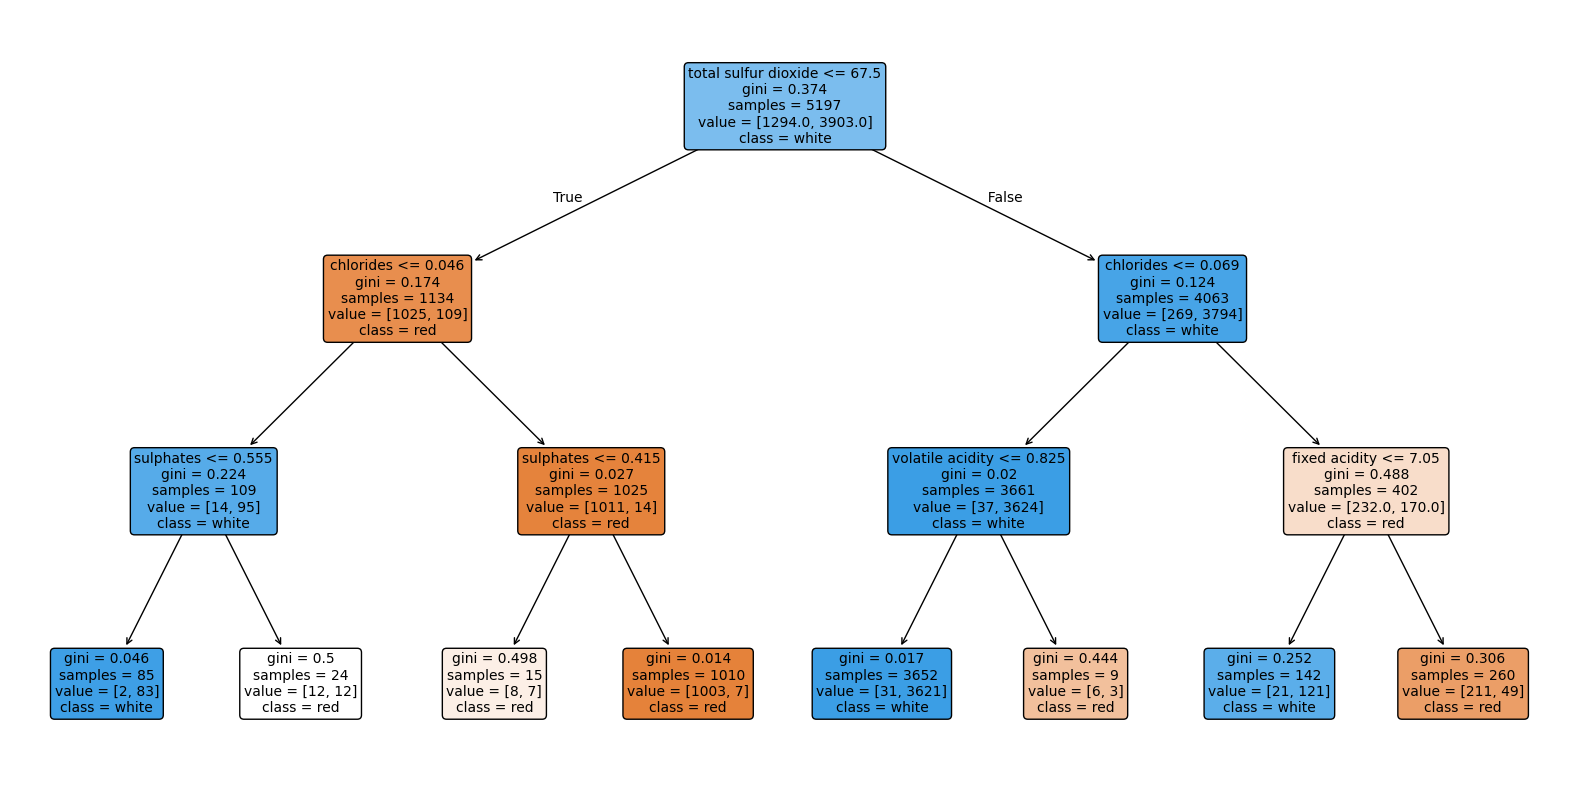

In [146]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=x.columns.tolist(), class_names=['red','white'], filled=True, rounded=True, fontsize=10)
plt.show()